In [1]:
%matplotlib inline

import subprocess
import os
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to read USEARCH output into a structured pandas DataFrame
def readUsearchOutputTodf(filename):
    # Read tab-delimited USEARCH output and manually assign expected column names
    df_usearch = pd.read_csv(filename, delimiter='\t',\
                             names=['query','target','id','alnlen','mism','opens','qlo','qhi',\
                                    'tlo','thi','evalue','bits','qrow','trow','qrowdots','tstrand','qstrand']) 
    return df_usearch

# Function to build a mutation frequency table from USEARCH alignment data
def createMutationFrequencyTablefromUsearch(filename, seqLength):
    # Load USEARCH results
    df_top = readUsearchOutputTodf(filename)
    
    # Create empty table with mutation symbols as row index
    df_trace = pd.DataFrame(index=['.','A','T','C','G','-'])
    
    # Loop through each position of the sequence
    for i in range(0, seqLength):
        # Count occurrences of each character at sequence position i
        df_trace_temp = df_top.qrowdots.str[i].value_counts('.').to_frame()
        # Name the column as the current index
        df_trace_temp.columns = [i]
        # Append the counts to the master table
        df_trace = df_trace.join(df_trace_temp)
    
    # Transpose so positions become rows
    df_mut = df_trace.transpose()
    # Replace missing values with zeros
    df_mut = df_mut.fillna(0)
    # Compute total mutation frequency at each position
    df_mut['Mutation_Frequency'] = df_mut['A'] + df_mut['T'] + df_mut['C'] + df_mut['G']
    
    return df_mut

# Convert USEARCH alignment output into simple value counts for each target sequence
def convertUsearchToValueCounts(inputFileName, countColumnName):
    """
    The following function converts the usearch input into a value counts output.
    The goal of the function is to reduce the usearch dataframes into simple readable value counts.
    
    Input:
        inputFileName: base filename of the USEARCH .txt file
        countColumnName: name to assign to the resulting count column
    
    Output:
        A dataframe with counts of each 'target' sequence from USEARCH
    """
    
    # Read the USEARCH output file from the "Usearch" directory
    df = readUsearchOutputTodf('Usearch/' + inputFileName + '.fq.txt')
    
    # Get read counts for each target sequence and rename column
    df_value_counts = pd.DataFrame(df.target.value_counts()).rename(columns={'target': countColumnName})
    
    return df_value_counts


In [2]:
#Read all the files from the usearch folder
split_files = os.listdir("Usearch/")
list_files = []
for file in split_files:
    list_files.append(file.split('.')[0])
list_files.remove('desktop')
list_files.remove('LF82-1')
#List of all read files
print(list_files)

['LF82-10', 'LF82-11', 'LF82-12', 'LF82-13', 'LF82-14', 'LF82-15', 'LF82-16', 'LF82-17', 'LF82-18', 'LF82-19', 'LF82-2', 'LF82-20', 'LF82-21', 'LF82-22', 'LF82-23', 'LF82-24', 'LF82-25', 'LF82-26', 'LF82-27', 'LF82-28', 'LF82-29', 'LF82-3', 'LF82-30', 'LF82-31', 'LF82-32', 'LF82-33', 'LF82-34', 'LF82-35', 'LF82-36', 'LF82-37', 'LF82-38', 'LF82-4', 'LF82-5', 'LF82-6', 'LF82-7', 'LF82-8', 'LF82-9']


In [3]:
#We initialize a dataframe with the first sampe
df_t0 = convertUsearchToValueCounts('LF82-1', 'LF82-1').rename(columns = {'count':'LF82-1'})

#To the initialized dataframe, we add the counts from all other samples
for column in list_files:
    print(column)
    df = convertUsearchToValueCounts(column, column).rename(columns = {'count':column})
    df_t0 = pd.concat([df_t0,df], axis = 1)

#To calculate the enrichlement, we replace 0 with 1. Log(0) or log(1/0) can pose problems
df_t0 = df_t0.replace(np.nan, 1)

LF82-10
LF82-11
LF82-12
LF82-13
LF82-14
LF82-15
LF82-16
LF82-17
LF82-18
LF82-19
LF82-2
LF82-20
LF82-21
LF82-22
LF82-23
LF82-24
LF82-25
LF82-26
LF82-27
LF82-28
LF82-29
LF82-3
LF82-30
LF82-31
LF82-32
LF82-33
LF82-34
LF82-35
LF82-36
LF82-37
LF82-38
LF82-4
LF82-5
LF82-6
LF82-7
LF82-8
LF82-9


In [4]:
import numpy as np
import pandas as pd

# Dictionaries to store newly computed columns before merging into df_t0
fraction_columns = {}
enrichment_columns = {}

# Loop through all time-point/sample columns listed in `list_files`
for column in list_files:

    # ---------------------------------------------------------
    # Create fraction column for each sample
    # (value + 0.5) / total counts in the column
    # ---------------------------------------------------------
    frac_col = column + "_f"   # name of new fraction column
    fraction_columns[frac_col] = (df_t0[column] + 0.5) / df_t0[column].sum()

    # Extract the sample number from the column name (e.g., "t-5" → 5)
    sample_number = int(column.replace("_f", "").split("-")[1])

    # Choose reference column depending on sample number
    # Samples <22 use LF82-1; samples ≥22 use LF82-22
    if sample_number < 22:
        ref_col = "LF82-1"
    else:
        ref_col = "LF82-22"

    # ---------------------------------------------------------
    # Compute enrichment relative to WT_1 ... WT_4
    # ---------------------------------------------------------
    for i in range(1, 5):
        wt_label = f"WT_{i}"     # wild-type reference strain
        enrich_col = frac_col.replace("_f", f"_enrichment{i}")  # name of new column

        # Enrichment formula:
        #   (sample_value / reference_value)
        #       divided by
        #   (sample_value_in_WT / reference_value_in_WT)
        #
        # Then take the natural logarithm.
        enrichment_columns[enrich_col] = (
            (df_t0[column] / df_t0[ref_col])
            / (df_t0.loc[wt_label, column] / df_t0.loc[wt_label, ref_col])
        ).apply(np.log)

# ---------------------------------------------------------
# Add all new fraction columns to df_t0 in one step
# ---------------------------------------------------------
df_t0 = pd.concat([df_t0, pd.DataFrame(fraction_columns)], axis=1)

# Add all new enrichment columns to df_t0
df_t0 = pd.concat([df_t0, pd.DataFrame(enrichment_columns)], axis=1)

# Optional: defragment the DataFrame to optimize internal memory layout
df_t0 = df_t0.copy()

df_t0.to_csv('5C-5H. Competition enrichment raw data.csv')


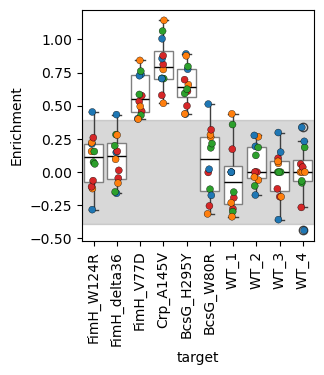

In [5]:
"""
Here we plot a change in enrichment on discs at 30 minutes.
"""

df_plot = df_t0.drop(['WT_Exp'])[['LF82-2_enrichment1','LF82-3_enrichment1','LF82-4_enrichment1',\
                'LF82-2_enrichment2','LF82-3_enrichment2','LF82-4_enrichment2',\
                'LF82-2_enrichment3','LF82-3_enrichment3','LF82-4_enrichment3',\
                'LF82-2_enrichment4','LF82-3_enrichment4','LF82-4_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order
df_plot = df_plot.sort_values('target')

plt.figure(figsize = [3,3])
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)
plt.xticks(rotation = 90);
#plt.xticks(np.arange(10), np.arange(10), rotation = 90, fontname = 'Arial', fontsize = 12);

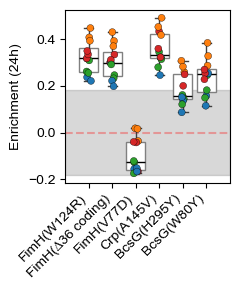

In [6]:
"""
Here we plot a change in enrichment in dsics at 24 hours in new discs.
"""

df_plot = df_t0.drop(['WT_Exp'])[['LF82-5_enrichment1','LF82-6_enrichment1','LF82-7_enrichment1',\
                'LF82-5_enrichment2','LF82-6_enrichment2','LF82-7_enrichment2',\
                'LF82-5_enrichment3','LF82-6_enrichment3','LF82-7_enrichment3',\
                'LF82-5_enrichment4','LF82-6_enrichment4','LF82-7_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order
df_plot = df_plot.sort_values('target')

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (24h)',fontname = 'Arial', fontsize = 10);
#plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/Biofilm.svg', format = 'svg', dpi = 300)

In [7]:
df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order
df_plot = df_plot.sort_values('target')


mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()

df_plot.target.value_counts()#.str.find('WT') >=0

target
FimH_W124R      12
FimH_delta36    12
FimH_V77D       12
Crp_A145V       12
BcsG_H295Y      12
BcsG_W80R       12
WT_1             0
WT_2             0
WT_3             0
WT_4             0
Name: count, dtype: int64

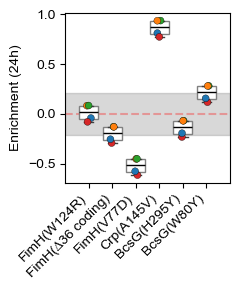

In [8]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in new discs.
"""

df_plot = df_t0.drop(['WT_Exp'])[['LF82-8_enrichment1','LF82-8_enrichment2','LF82-8_enrichment3','LF82-8_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order
df_plot = df_plot.sort_values('target')

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (24h)',fontname = 'Arial', fontsize = 10);
#plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()

plt.tight_layout()
plt.savefig('Figures/Biofilm_plnk.svg', format = 'svg', dpi = 300)

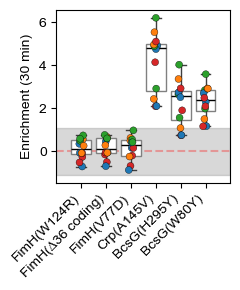

In [9]:
"""
Here we plot a change in enrichment in discs at 24 hours in discs populated with wildtype cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-35_enrichment1','LF82-36_enrichment1','LF82-37_enrichment1',\
                'LF82-35_enrichment2','LF82-36_enrichment2','LF82-37_enrichment2',\
                'LF82-35_enrichment3','LF82-36_enrichment3','LF82-37_enrichment3',\
                'LF82-35_enrichment4','LF82-36_enrichment4','LF82-37_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order
df_plot = df_plot.sort_values('target')

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
#plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.tight_layout()
plt.savefig('Figures/Biofilm_inv.svg', format = 'svg', dpi = 300)

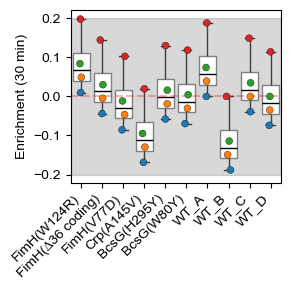

In [10]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with wildtype cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-38_enrichment1','LF82-38_enrichment2','LF82-38_enrichment3','LF82-38_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order
df_plot = df_plot.sort_values('target')

plt.figure(figsize = [3,3])
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)
plt.xticks(np.arange(10), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)',\
                          'WT_A','WT_B','WT_C','WT_D'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
#plt.ylim([-2.5,1.5])
plt.tight_layout()
plt.savefig('Figures/Biofilm_inv_plnk.svg', format = 'svg', dpi = 300)

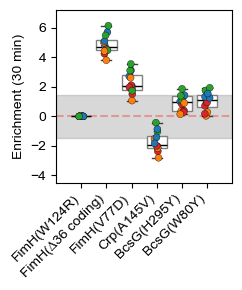

In [11]:
"""
Here we plot a change in enrichment in discs at 24 hours in discs populated with fimW124R cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-12_enrichment1','LF82-10_enrichment1','LF82-11_enrichment1',\
                'LF82-12_enrichment2','LF82-10_enrichment2','LF82-11_enrichment2',\
                'LF82-12_enrichment3','LF82-10_enrichment3','LF82-11_enrichment3',\
                'LF82-12_enrichment4','LF82-10_enrichment4','LF82-11_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot.loc[df_plot.target == 'FimH_W124R', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/fimH_W124R.svg', format = 'svg', dpi = 300)

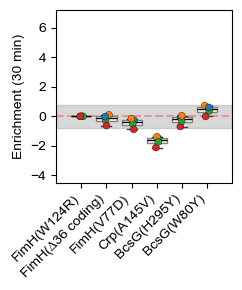

In [12]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with fimW124R cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-13_enrichment1','LF82-13_enrichment2','LF82-13_enrichment3','LF82-13_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'FimH_W124R', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/fimH_W124R_plnk.svg', format = 'svg', dpi = 300)

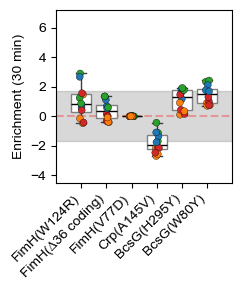

In [13]:
"""
Here we plot a change in enrichment in Discs at 24 hours in discs populated with FimV77D cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-14_enrichment1','LF82-15_enrichment1','LF82-16_enrichment1',\
                'LF82-14_enrichment2','LF82-15_enrichment2','LF82-16_enrichment2',\
                'LF82-14_enrichment3','LF82-15_enrichment3','LF82-16_enrichment3',\
                'LF82-14_enrichment4','LF82-15_enrichment4','LF82-16_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'FimH_V77D', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/fimH_V77D.svg', format = 'svg', dpi = 300)

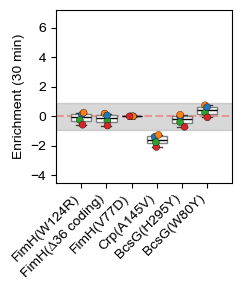

In [14]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with FimV77D cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-17_enrichment1','LF82-17_enrichment2','LF82-17_enrichment3','LF82-17_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'FimH_V77D', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/fimH_V77D_plnk.svg', format = 'svg', dpi = 300)

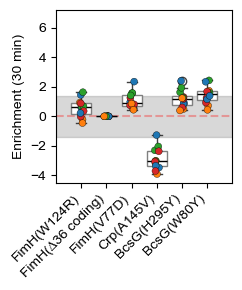

In [15]:
"""
Here we plot a change in enrichment in discs at 24 hours in discs populated with Fim delta36 cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-18_enrichment1','LF82-19_enrichment1','LF82-20_enrichment1',\
                'LF82-18_enrichment2','LF82-19_enrichment2','LF82-20_enrichment2',\
                'LF82-18_enrichment3','LF82-19_enrichment3','LF82-20_enrichment3',\
                'LF82-18_enrichment4','LF82-19_enrichment4','LF82-20_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'FimH_delta36', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/fimH_del36.svg', format = 'svg', dpi = 300)

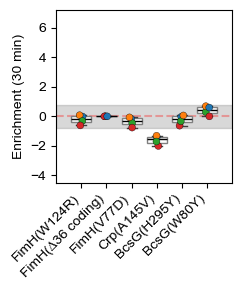

In [16]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with Fim delta36 cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-21_enrichment1','LF82-21_enrichment2','LF82-21_enrichment3','LF82-21_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'FimH_delta36', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/fimH_del36_plnk.svg', format = 'svg', dpi = 300)

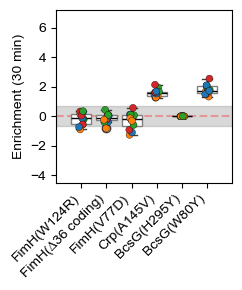

In [17]:
"""
Here we plot a change in enrichment in Discs at 24 hours in discs populated with BcsG H295Y cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-23_enrichment1','LF82-24_enrichment1','LF82-25_enrichment1',\
                'LF82-23_enrichment2','LF82-24_enrichment2','LF82-25_enrichment2',\
                'LF82-23_enrichment3','LF82-24_enrichment3','LF82-25_enrichment3',\
                'LF82-23_enrichment4','LF82-24_enrichment4','LF82-25_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'BcsG_H295Y', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/bcsG_H295Y.svg', format = 'svg', dpi = 300)

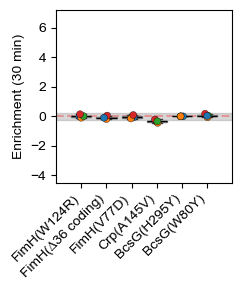

In [18]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with BcsG H295Y cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-26_enrichment1','LF82-26_enrichment2','LF82-26_enrichment3','LF82-26_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'BcsG_H295Y', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/bcsG_H295Y_pnk.svg', format = 'svg', dpi = 300)

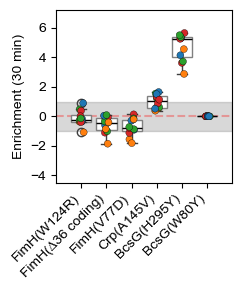

In [19]:
"""
Here we plot a change in enrichment in discs at 24 hours in discs populated with BcsG W80Y cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-27_enrichment1','LF82-28_enrichment1','LF82-29_enrichment1',\
                'LF82-27_enrichment2','LF82-28_enrichment2','LF82-29_enrichment2',\
                'LF82-27_enrichment3','LF82-28_enrichment3','LF82-29_enrichment3',\
                'LF82-27_enrichment4','LF82-28_enrichment4','LF82-29_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'BcsG_W80R', 'Enrichment'] = 0

df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/bcsG_W80Y.svg', format = 'svg', dpi = 300)

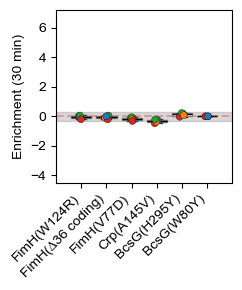

In [21]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with BcsG W80Y cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-30_enrichment1','LF82-30_enrichment2','LF82-30_enrichment3','LF82-30_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'BcsG_W80R', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/bcsG_W80Y_plnk.svg', format = 'svg', dpi = 300)

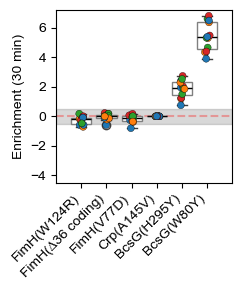

In [22]:
"""
Here we plot a change in enrichment in discs at 24 hours in discs populated with Crp A145V cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-31_enrichment1','LF82-32_enrichment1','LF82-33_enrichment1',\
                'LF82-31_enrichment2','LF82-32_enrichment2','LF82-33_enrichment2',\
                'LF82-31_enrichment3','LF82-32_enrichment3','LF82-33_enrichment3',\
                'LF82-31_enrichment4','LF82-32_enrichment4','LF82-33_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'Crp_A145V', 'Enrichment'] = 0

df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/crp_145V.svg', format = 'svg', dpi = 300)

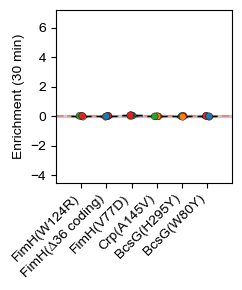

In [23]:
"""
Here we plot a change in enrichment in planktonic at 24 hours in discs populated with Crp A145V cells.
"""

df_t0['Gene'] = df_t0.index.str.split('_').str[0]
df_plot = df_t0.drop(['WT_Exp'])[['LF82-34_enrichment1','LF82-34_enrichment2','LF82-34_enrichment3','LF82-34_enrichment4']]\
.stack().reset_index().rename(columns={'level_1':'Sample',0:'Enrichment'})
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
df_plot.loc[df_plot.target == 'Crp_A145V', 'Enrichment'] = 0
df_plot['Reference'] = df_plot.Sample.str.split('_').str[1]
# Define your desired order
order = ['FimH_W124R', 'FimH_delta36', 'FimH_V77D', 'Crp_A145V','BcsG_H295Y', 'BcsG_W80R','WT_1','WT_2','WT_3','WT_4']
df_plot['target'] = pd.Categorical(df_plot['target'], categories=order, ordered=True)
# Sort by this custom order

plt.figure(figsize = [2.5,3])
df_plot = df_plot.sort_values('target')

mean_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.mean()
std_wt = df_plot[df_plot.target.str.find('WT') >=0].Enrichment.std()
plt.axhline(y = mean_wt, color = 'red', alpha= 0.3, linestyle ='--')
plt.axhspan(ymin=mean_wt-1.96*std_wt, ymax=mean_wt+1.96*std_wt, color = 'gray', alpha= 0.3)

df_plot = df_plot[df_plot.target.str.find('WT') < 0]
sns.stripplot(data=df_plot, x="target", y="Enrichment", hue = 'Reference', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='target', y='Enrichment', data=df_plot,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))


plt.xticks(np.arange(6), ['FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',\
                           'Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],  rotation = 45,ha = 'right', fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.xlabel('',fontname = 'Arial', fontsize = 10);
plt.ylabel('Enrichment (30 min)',fontname = 'Arial', fontsize = 10);
plt.ylim([-4.5,7.2])
plt.xlim([-1,6])
plt.tight_layout()
plt.savefig('Figures/crp_145V_plnk.svg', format = 'svg', dpi = 300)

In [24]:
df_CSV.Strain.value_counts()

NameError: name 'df_CSV' is not defined

In [ ]:
#Load the raw Crystal Violet Data
df_CSV = pd.read_csv('BiofilmFormation_CV_on_Disc_raw.csv')

# Create a combined strain name (e.g., Gene + Mutation)
df_CSV['Strain'] = df_CSV.Gene + '_' + df_CSV.Mutation


# Define custom strain order for plotting
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V', 'Crp_A145T', 'BcsG_H295Y', 'BcsG_W80R']

# Convert to ordered categorical for consistent sorting in plots
df_CSV['Strain'] = pd.Categorical(df_CSV['Strain'],
                                             categories=order, ordered=True)


# Sort rows based on ordered strain
df_CSV = df_CSV.sort_values('Strain')

# Begin figure for normalized CV/CFU
plt.figure(figsize=[3,3])

# Overlay individual points
sns.stripplot(data=df_CSV, x="Strain", y="OD",
              s=4, edgecolor='black', linewidth=0.25, legend=False)

# Overlay white boxplot with gray edges
sns.boxplot(x='Strain', y='OD', data=df_CSV,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)
plt.yticks(fontname='Arial', fontsize=10)

plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('Crystal violet\n(optical density)', fontname='Arial', fontsize=10)

# Manually set display labels
plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145T)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)

plt.tight_layout()

plt.savefig('Figures/CV raw.svg', format='svg', dpi=300)


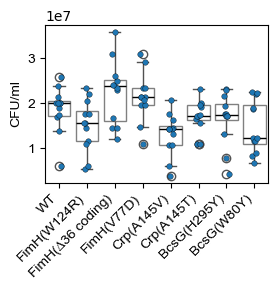

In [25]:
#Load the raw Crystal Violet Data
df_CSV = pd.read_csv('BiofilmFormation_CV_on_Disc_raw.csv')

# Create a combined strain name (e.g., Gene + Mutation)
df_CSV['Strain'] = df_CSV.Gene + '_' + df_CSV.Mutation


# Define custom strain order for plotting
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V', 'Crp_A145T', 'BcsG_H295Y', 'BcsG_W80R']

# Convert to ordered categorical for consistent sorting in plots
df_CSV['Strain'] = pd.Categorical(df_CSV['Strain'],
                                             categories=order, ordered=True)


# Sort rows based on ordered strain
df_CSV = df_CSV.sort_values('Strain')

# Begin figure for normalized CV/CFU
plt.figure(figsize=[3,3])

# Overlay individual points
sns.stripplot(data=df_CSV, x="Strain", y="CFU",
              s=4, edgecolor='black', linewidth=0.25, legend=False)

# Overlay white boxplot with gray edges
sns.boxplot(x='Strain', y='CFU', data=df_CSV,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)
plt.yticks(fontname='Arial', fontsize=10)

plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('CFU/ml', fontname='Arial', fontsize=10)

# Manually set display labels
plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145T)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)

plt.tight_layout()

plt.savefig('Figures/CFU raw.svg', format='svg', dpi=300)


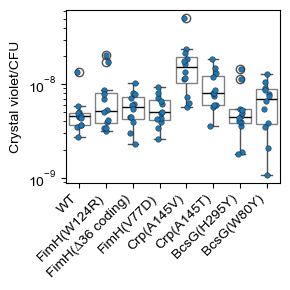

In [26]:
#Load the raw Crystal Violet Data
df_CSV = pd.read_csv('BiofilmFormation_CV_on_Disc_raw.csv')

# Create a combined strain name (e.g., Gene + Mutation)
df_CSV['Strain'] = df_CSV.Gene + '_' + df_CSV.Mutation
df_CSV['CV_norm'] = df_CSV['OD']/df_CSV['CFU']


# Define custom strain order for plotting
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V', 'Crp_A145T', 'BcsG_H295Y', 'BcsG_W80R']

# Convert to ordered categorical for consistent sorting in plots
df_CSV['Strain'] = pd.Categorical(df_CSV['Strain'],
                                             categories=order, ordered=True)


# Sort rows based on ordered strain
df_CSV = df_CSV.sort_values('Strain')

# Begin figure for normalized CV/CFU
plt.figure(figsize=[3,3])

# Overlay individual points
sns.stripplot(data=df_CSV, x="Strain", y="CV_norm",
              s=4, edgecolor='black', linewidth=0.25, legend=False)

# Overlay white boxplot with gray edges
sns.boxplot(x='Strain', y='CV_norm', data=df_CSV,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)
plt.yticks(fontname='Arial', fontsize=10)

plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('Crystal violet/CFU', fontname='Arial', fontsize=10)

# Manually set display labels
plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145T)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)

plt.yscale('log')

plt.tight_layout()

plt.savefig('Figures/CV_norm.svg', format='svg', dpi=300)


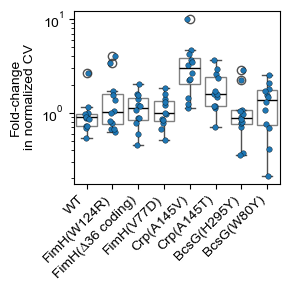

In [27]:
#Load the raw Crystal Violet Data
df_CSV = pd.read_csv('BiofilmFormation_CV_on_Disc_raw.csv')

# Create a combined strain name (e.g., Gene + Mutation)
df_CSV['Strain'] = df_CSV.Gene + '_' + df_CSV.Mutation
df_CSV['CV_norm'] = df_CSV['OD']/df_CSV['CFU']
df_CSV['CV_rel'] = df_CSV['CV_norm']/df_CSV.loc[df_CSV.Gene == 'WT'].CV_norm.mean()


# Define custom strain order for plotting
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V', 'Crp_A145T', 'BcsG_H295Y', 'BcsG_W80R']

# Convert to ordered categorical for consistent sorting in plots
df_CSV['Strain'] = pd.Categorical(df_CSV['Strain'],
                                             categories=order, ordered=True)


# Sort rows based on ordered strain
df_CSV = df_CSV.sort_values('Strain')

# Begin figure for normalized CV/CFU
plt.figure(figsize=[3,3])

# Overlay individual points
sns.stripplot(data=df_CSV, x="Strain", y="CV_rel",
              s=4, edgecolor='black', linewidth=0.25, legend=False)

# Overlay white boxplot with gray edges
sns.boxplot(x='Strain', y='CV_rel', data=df_CSV,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)
plt.yticks(fontname='Arial', fontsize=10)

plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('Fold-change\nin normalized CV', fontname='Arial', fontsize=10)

# Manually set display labels
plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145T)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)

plt.yscale('log')

plt.tight_layout()

plt.savefig('Figures/CV_rel.svg', format='svg', dpi=300)


In [28]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "CV_rel"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "CV_rel"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,138.0,0.000156,0.001091
4,A145T,124.0,0.002946,0.010310
1,del36,91.0,0.285476,0.469588
0,W124R,87.0,0.402504,0.469588
2,V77D,87.0,0.402504,0.469588
6,W80R,93.0,0.236584,0.469588
5,H295Y,74.0,0.930987,0.930987


In [29]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "CV_norm"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "CV_norm"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,138.0,0.000156,0.001091
4,A145T,124.0,0.002946,0.010310
1,del36,91.0,0.285476,0.469588
0,W124R,87.0,0.402504,0.469588
2,V77D,87.0,0.402504,0.469588
6,W80R,93.0,0.236584,0.469588
5,H295Y,74.0,0.930987,0.930987


In [30]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "OD"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "OD"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,140.5,0.000086,0.000545
4,A145T,138.0,0.000156,0.000545
1,del36,119.0,0.007235,0.016881
2,V77D,113.0,0.019373,0.033903
5,H295Y,46.0,0.140955,0.197337
6,W80R,61.0,0.544283,0.634996
0,W124R,75.5,0.862431,0.862431


In [31]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "CFU"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "CFU"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,26.5,0.009221,0.064548
0,W124R,45.5,0.132736,0.236188
1,del36,96.0,0.174384,0.236188
2,V77D,94.5,0.202447,0.236188
4,A145T,47.0,0.156038,0.236188
6,W80R,45.5,0.132736,0.236188
5,H295Y,54.0,0.311373,0.311373


In [32]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "CV_norm"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "CV_norm"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,138.0,0.000156,0.001091
4,A145T,124.0,0.002946,0.010310
1,del36,91.0,0.285476,0.469588
0,W124R,87.0,0.402504,0.469588
2,V77D,87.0,0.402504,0.469588
6,W80R,93.0,0.236584,0.469588
5,H295Y,74.0,0.930987,0.930987


In [33]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "OD"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "OD"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,140.5,0.000086,0.000545
4,A145T,138.0,0.000156,0.000545
1,del36,119.0,0.007235,0.016881
2,V77D,113.0,0.019373,0.033903
5,H295Y,46.0,0.140955,0.197337
6,W80R,61.0,0.544283,0.634996
0,W124R,75.5,0.862431,0.862431


In [34]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV.loc[df_CSV.Mutation == 'A',
                                  "CFU"]

# List all unique mutants except WT
mutants = df_CSV.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV.loc[df_CSV.Mutation == mutant,
                                       "CFU"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,26.5,0.009221,0.064548
0,W124R,45.5,0.132736,0.236188
1,del36,96.0,0.174384,0.236188
2,V77D,94.5,0.202447,0.236188
4,A145T,47.0,0.156038,0.236188
6,W80R,45.5,0.132736,0.236188
5,H295Y,54.0,0.311373,0.311373


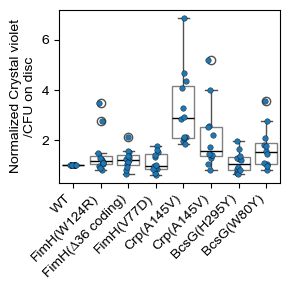

In [35]:
# Load normalized crystal violet dataset
df_CSV_normalised = pd.read_csv('BiofilmFormation_CVnomalized_on_Disc.csv')

# Create a combined strain name (e.g., Gene + Mutation)
df_CSV_normalised['Strain'] = df_CSV_normalised.Gene + '_' + df_CSV_normalised.Mutation

# Define custom strain order for plotting
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V', 'Crp_A145T', 'BcsG_H295Y', 'BcsG_W80R']

# Convert to ordered categorical for consistent sorting in plots
df_CSV_normalised['Strain'] = pd.Categorical(df_CSV_normalised['Strain'],
                                             categories=order, ordered=True)

# Sort rows based on ordered strain
df_CSV_normalised = df_CSV_normalised.sort_values('Strain')

# Begin figure for normalized CV/CFU
plt.figure(figsize=[3,3])

# Overlay individual points
sns.stripplot(data=df_CSV_normalised, x="Strain", y="FoldWT_GrowthNorm",
              s=4, edgecolor='black', linewidth=0.25, legend=False)

# Overlay white boxplot with gray edges
sns.boxplot(x='Strain', y='FoldWT_GrowthNorm', data=df_CSV_normalised,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)
plt.yticks(fontname='Arial', fontsize=10)

plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('Normalized Crystal violet\n/CFU on disc', fontname='Arial', fontsize=10)

# Manually set display labels
plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)

plt.tight_layout()

# Save figure
plt.savefig('Figures/Normalized CV.svg', format='svg', dpi=300)


In [36]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV_normalised.loc[df_CSV_normalised.Mutation == 'A',
                                  "FoldWT_GrowthNorm"]

# List all unique mutants except WT
mutants = df_CSV_normalised.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV_normalised.loc[df_CSV_normalised.Mutation == mutant,
                                       "FoldWT_GrowthNorm"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,144.0,0.000010,0.000072
4,A145T,132.0,0.000242,0.000845
6,W80R,120.0,0.003382,0.007892
0,W124R,108.0,0.028503,0.039904
1,del36,108.0,0.028503,0.039904
2,V77D,60.0,0.477995,0.557661
5,H295Y,72.0,1.000000,1.000000


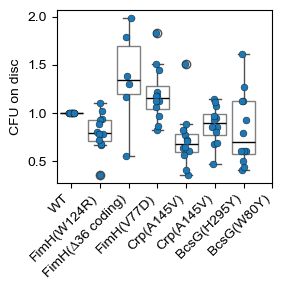

In [37]:
# Load dataset (CFU fold change relative to WT)
df_CSV_normalised = pd.read_csv('BiofilmFormation_CFU_on_Disc.csv')

# Construct strain name from Gene + Mutation
df_CSV_normalised['Strain'] = df_CSV_normalised.Gene + '_' + df_CSV_normalised.Mutation

# Define plotting order
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V','BcsG_H295Y', 'BcsG_W80R']

# Apply ordered categories and sort
df_CSV_normalised['Strain'] = pd.Categorical(df_CSV_normalised['Strain'],
                                             categories=order, ordered=True)
df_CSV_normalised = df_CSV_normalised.sort_values('Strain')

# Begin plot
plt.figure(figsize=[3,3])

# Add points
sns.stripplot(data=df_CSV_normalised, x="Strain", y="CFUfold",
              s=5, edgecolor='black', linewidth=0.25, legend=False)

# Add boxplots
sns.boxplot(x='Strain', y='CFUfold', data=df_CSV_normalised,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)

# Manually set display labels


plt.yticks(fontname='Arial', fontsize=10)
plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('CFU on disc', fontname='Arial', fontsize=10)

plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)


plt.tight_layout()

plt.savefig('Figures/CFU on disc.svg', format='svg', dpi=300)


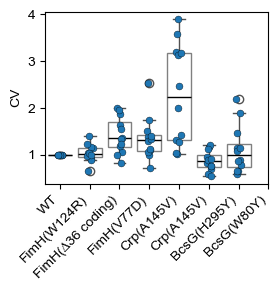

In [38]:
# Load crystal violet absorbance data
df_CSV_normalised = pd.read_csv('BiofilmFormation_CV_on_Disc.csv')

# Build strain identifier
df_CSV_normalised['Strain'] = df_CSV_normalised.Gene + '_' + df_CSV_normalised.Mutation

# Define ordered strain categories
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V','BcsG_H295Y', 'BcsG_W80R']

# Apply ordering and sort
df_CSV_normalised['Strain'] = pd.Categorical(df_CSV_normalised['Strain'],
                                             categories=order, ordered=True)
df_CSV_normalised = df_CSV_normalised.sort_values('Strain')

plt.figure(figsize=[3,3])

# Add raw points
sns.stripplot(data=df_CSV_normalised, x="Strain", y="Fold_WT_CV",
              s=5, edgecolor='black', linewidth=0.25, legend=False)

# Add boxplot
sns.boxplot(x='Strain', y='Fold_WT_CV', data=df_CSV_normalised,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

plt.yticks(fontname='Arial', fontsize=10)
plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('CV', fontname='Arial', fontsize=10)

plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)


plt.tight_layout()

plt.savefig('Figures/Fold_WT_CV.svg', format='svg', dpi=300)

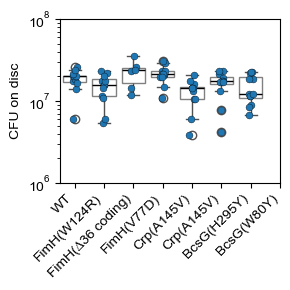

In [39]:
# Load CFU dataset
df_CSV_normalised = pd.read_csv('BiofilmFormation_CFU_on_Disc2.csv')

# Combine Gene + Mutation to form strain name
df_CSV_normalised['Strain'] = df_CSV_normalised.Gene + '_' + df_CSV_normalised.Mutation

# Apply ordered strain list
order = ['WT_A','FimH_W124R', 'FimH_del36', 'FimH_V77D',
         'Crp_A145V','BcsG_H295Y', 'BcsG_W80R']

df_CSV_normalised['Strain'] = pd.Categorical(df_CSV_normalised['Strain'],
                                             categories=order, ordered=True)
df_CSV_normalised = df_CSV_normalised.sort_values('Strain')

plt.figure(figsize=[3,3])

# Scatter points
sns.stripplot(data=df_CSV_normalised, x="Strain", y="CFU",
              s=5, edgecolor='black', linewidth=0.25, legend=False)

# Boxplot overlay
sns.boxplot(x='Strain', y='CFU', data=df_CSV_normalised,
            boxprops=dict(facecolor='white', edgecolor='gray'),
            medianprops=dict(color='black'))

plt.xticks(rotation=45, ha='right', fontname='Arial', fontsize=10)
plt.yticks(fontname='Arial', fontsize=10)
plt.xlabel('', fontname='Arial', fontsize=10)
plt.ylabel('CFU on disc', fontname='Arial', fontsize=10)

# Log scale (important for CFU data)
plt.yscale('log')
plt.ylim([1_000_000, 10**8])

plt.xticks(np.arange(8),
           ['WT','FimH(W124R)','FimH(∆36 coding)','FimH(V77D)',
            'Crp(A145V)','Crp(A145V)','BcsG(H295Y)','BcsG(W80Y)'],
           rotation=45, ha='right', fontname='Arial', fontsize=10)

plt.tight_layout()

plt.savefig('Figures/CFU.svg', format='svg', dpi=300)


In [40]:
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

# Extract WT values (Mutation == 'A')
wt_values = df_CSV_normalised.loc[df_CSV_normalised.Mutation == 'A',
                                  "CFU"]

# List all unique mutants except WT
mutants = df_CSV_normalised.Mutation.unique()
mutants = [m for m in mutants if m != 'A']

results = []

# Perform pairwise Mann–Whitney U comparing each mutant vs WT
for mutant in mutants:
    mut_values = df_CSV_normalised.loc[df_CSV_normalised.Mutation == mutant,
                                       "CFU"]

    # Two-sided U test
    stat, pval = stats.mannwhitneyu(mut_values, wt_values, alternative="two-sided")

    # Store results
    results.append({"Mutation": mutant, "U_stat": stat, "pval": pval})

# Convert list of results to dataframe
df_results = pd.DataFrame(results)

# Apply Benjamini–Hochberg multiple testing correction
df_results["pval_adj"] = smm.multipletests(df_results["pval"],
                                           method="fdr_bh")[1]

# Sort by adjusted p-value
df_results = df_results.sort_values("pval_adj")

# Display results
df_results


,Mutation,U_stat,pval,pval_adj
3,A145V,26.5,0.009221,0.073770
0,W124R,45.5,0.132736,0.311373
1,del36,48.0,0.280452,0.311373
2,V77D,94.5,0.202447,0.311373
4,H295Y,54.0,0.311373,0.311373
5,W80R,45.5,0.132736,0.311373
6,A145T,47.0,0.156038,0.311373
7,∆86-121,48.0,0.280452,0.311373


In [41]:
# Create a dataframe for WT by averaging enrichment1–4 across strains LF82-35, LF82-36, LF82-37
df_wt = pd.DataFrame(
    df_t0[
        [
            'LF82-35_enrichment1','LF82-35_enrichment2','LF82-35_enrichment3','LF82-35_enrichment4',
            'LF82-36_enrichment1','LF82-36_enrichment2','LF82-36_enrichment3','LF82-36_enrichment4',
            'LF82-37_enrichment1','LF82-37_enrichment2','LF82-37_enrichment3','LF82-37_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'WT'})

# FimH_W124R mutant: average enrichment values from strains LF82-10, 11, 12
df_fimh1 = pd.DataFrame(
    df_t0[
        [
            'LF82-10_enrichment1','LF82-10_enrichment2','LF82-10_enrichment3','LF82-10_enrichment4',
            'LF82-11_enrichment1','LF82-11_enrichment2','LF82-11_enrichment3','LF82-11_enrichment4',
            'LF82-12_enrichment1','LF82-12_enrichment2','LF82-12_enrichment3','LF82-12_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'FimH_W124R'})

# FimH_V77D mutant: average enrichment from strains LF82-14, 15, 16
df_fimh2 = pd.DataFrame(
    df_t0[
        [
            'LF82-14_enrichment1','LF82-14_enrichment2','LF82-14_enrichment3','LF82-14_enrichment4',
            'LF82-15_enrichment1','LF82-15_enrichment2','LF82-15_enrichment3','LF82-15_enrichment4',
            'LF82-16_enrichment1','LF82-16_enrichment2','LF82-16_enrichment3','LF82-16_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'FimH_V77D'})

# FimH_delta36 mutant: average enrichment from strains LF82-18, 19, 20
df_fimh3 = pd.DataFrame(
    df_t0[
        [
            'LF82-18_enrichment1','LF82-18_enrichment2','LF82-18_enrichment3','LF82-18_enrichment4',
            'LF82-19_enrichment1','LF82-19_enrichment2','LF82-19_enrichment3','LF82-19_enrichment4',
            'LF82-20_enrichment1','LF82-20_enrichment2','LF82-20_enrichment3','LF82-20_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'FimH_delta36'})

# BcsG_H295Y mutant: strains LF82-23, 24, 25
df_BcsG1 = pd.DataFrame(
    df_t0[
        [
            'LF82-23_enrichment1','LF82-23_enrichment2','LF82-23_enrichment3','LF82-23_enrichment4',
            'LF82-24_enrichment1','LF82-24_enrichment2','LF82-24_enrichment3','LF82-24_enrichment4',
            'LF82-25_enrichment1','LF82-25_enrichment2','LF82-25_enrichment3','LF82-25_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'BcsG_H295Y'})

# BcsG_W80R mutant: strains LF82-27, 28, 29
df_BcsG2 = pd.DataFrame(
    df_t0[
        [
            'LF82-27_enrichment1','LF82-27_enrichment2','LF82-27_enrichment3','LF82-27_enrichment4',
            'LF82-28_enrichment1','LF82-28_enrichment2','LF82-28_enrichment3','LF82-28_enrichment4',
            'LF82-29_enrichment1','LF82-29_enrichment2','LF82-29_enrichment3','LF82-29_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'BcsG_W80R'})

# Crp_A145V mutant: strains LF82-31, 32, 33
df_crp = pd.DataFrame(
    df_t0[
        [
            'LF82-31_enrichment1','LF82-31_enrichment2','LF82-31_enrichment3','LF82-31_enrichment4',
            'LF82-32_enrichment1','LF82-32_enrichment2','LF82-32_enrichment3','LF82-32_enrichment4',
            'LF82-33_enrichment1','LF82-33_enrichment2','LF82-33_enrichment3','LF82-33_enrichment4'
        ]
    ].mean(axis=1)
).rename(columns={0: 'Crp_A145V'})

# Combine all mutant and WT enrichment summaries into one dataframe
df_summary = pd.concat(
    [df_wt, df_BcsG1, df_BcsG2, df_crp, df_fimh2, df_fimh1, df_fimh3],
    axis=1
)

# Remove rows where the index contains 'WT' and sort rows alphabetically
df_summary = df_summary.loc[df_summary.index.str.find('WT') < 0].sort_index()

# Set diagonal mutation-mutant entries to NaN (self-interaction values are meaningless)
df_summary.loc['BcsG_H295Y','BcsG_H295Y'] = np.nan
df_summary.loc['BcsG_W80R','BcsG_W80R'] = np.nan
df_summary.loc['Crp_A145V','Crp_A145V'] = np.nan
df_summary.loc['FimH_V77D','FimH_V77D'] = np.nan
df_summary.loc['FimH_W124R','FimH_W124R'] = np.nan
df_summary.loc['FimH_delta36','FimH_delta36'] = np.nan

df_summary


,WT,BcsG_H295Y,BcsG_W80R,Crp_A145V,FimH_V77D,FimH_W124R,FimH_delta36
target,,,,,,,
BcsG_H295Y,2.250058,NaN,4.724994,1.866371,1.132273,0.917942,1.182224
BcsG_W80R,2.305554,1.795152,NaN,5.419081,1.462860,1.028624,1.437840
Crp_A145V,4.173039,1.574875,0.992012,NaN,-1.791626,-1.715120,-2.887128
FimH_V77D,0.148530,-0.299957,-0.708809,-0.161547,NaN,2.278096,1.091122
FimH_W124R,0.103652,-0.169128,-0.110122,-0.253401,0.960557,NaN,0.559860
FimH_delta36,0.154178,-0.118409,-0.557765,-0.035621,0.387184,4.846145,NaN


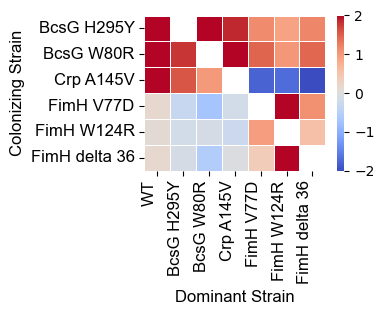

In [42]:
# Create a new figure with a set size
plt.figure(figsize=[4, 3.25])

# Draw heatmap of df_summary with custom styling
ax = sns.heatmap(
    df_summary,                  # matrix to plot
    annot=False,                 # do not write numbers inside cells
    cmap="coolwarm",             # diverging colormap
    fmt=".3f",                   # formatting (ignored since annot=False)
    cbar_kws={'label': ''},      # empty colorbar label
    center=0,                    # center colormap at zero
    vmin=-2, vmax=2,             # fix color scale range
    linewidths=0.5,              # thin white grid lines
    linecolor='white'            # grid line color
)

# Set custom x-axis tick positions and labels
plt.xticks(
    [0.5,1.5,2.5,3.5,4.5,5.5,6.5],     # center of each column
    ['WT', 'BcsG H295Y', 'BcsG W80R', 'Crp A145V', 'FimH V77D', 'FimH W124R', 'FimH delta 36'], 
    fontname='Arial',
    rotation=90,                       # vertical labels
    ha='right',                        # right-aligned
    fontsize=12
)

# Set custom y-axis tick positions and labels  
plt.yticks(
    [0.5,1.5,2.5,3.5,4.5,5.5],          # center of each row
    ['BcsG H295Y', 'BcsG W80R', 'Crp A145V', 'FimH V77D', 'FimH W124R', 'FimH delta 36'],
    fontname='Arial',
    fontsize=12
)

# Axis labels
plt.xlabel('Dominant Strain', fontname='Arial', fontsize=12)
plt.ylabel('Colonizing Strain', fontname='Arial', fontsize=12)

# Tight layout to avoid clipping
plt.tight_layout()

# Save figure as SVG
plt.savefig('Figures/Summary.svg', format='svg', dpi=300)
